In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")  

1. Data Loading

In [345]:
# Set the style of the plot
sns.set_style("whitegrid")

In [346]:
# Load data
data = pd.read_csv("../data.csv")

In [347]:
# Rename columns
data.columns = ['customer_happiness', 'delivery_timeliness','order_accuracy','product_availability',
              'price_value_perception','courier_service_rating', 'app_usability']

In [348]:
# Basic overview of the data
data.head()

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [349]:
data.tail()

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


In [350]:
data.info()
data.describe(include = 'all')

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   customer_happiness      126 non-null    int64
 1   delivery_timeliness     126 non-null    int64
 2   order_accuracy          126 non-null    int64
 3   product_availability    126 non-null    int64
 4   price_value_perception  126 non-null    int64
 5   courier_service_rating  126 non-null    int64
 6   app_usability           126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


2. Data Quality Checks

2.1 Null check remove null rows.

In [351]:
# Count number of rows with null values
num_rows_with_nulls = data.isnull().any(axis=1).sum()
print(f"Number of rows with at least one null value: {num_rows_with_nulls}")

Number of rows with at least one null value: 0


In [352]:
# Drop rows with null values
data = data.dropna()

2.2. Duplicate check remove duplictae row.

In [353]:
# Count number of duplicate rows
num_duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 16


In [354]:
# Remove duplicate rows
data = data.drop_duplicates()

2.3 Type errors and impossible values.

In [355]:
X = data.drop("customer_happiness", axis=1)
y = data["customer_happiness"]

In [356]:
# Counts of each unique value for customer_happiness
y.value_counts()

customer_happiness
1    56
0    54
Name: count, dtype: int64

In [ ]:
# Check that all values for customer_happiness are either 0 or 1
valid_values = {0, 1}
invalid_count = (~y.isin(valid_values)).sum()
print(f"Number of rows with values other than 0 or 1: {invalid_count}")
if invalid_count == 0:
    print("All values in customer_happiness are either 0 or 1")

Number of rows with values other than 0 or 1: 0
All values in customer_happiness are either 0 or 1


In [358]:
# Drop rows where customer_happiness is not 0 or 1
data = data[data['customer_happiness'].isin({0, 1})]

In [359]:
# Counts of each unique value for each feature
for col in X.columns:
    print(f"Different values with count for {col}: {X[col].value_counts()}") 

Different values with count for delivery_timeliness: delivery_timeliness
5    55
4    36
3    18
1     1
Name: count, dtype: int64
Different values with count for order_accuracy: order_accuracy
3    37
2    30
1    23
4    15
5     5
Name: count, dtype: int64
Different values with count for product_availability: product_availability
3    50
4    27
5    14
2    13
1     6
Name: count, dtype: int64
Different values with count for price_value_perception: price_value_perception
4    46
3    35
5    22
2     5
1     2
Name: count, dtype: int64
Different values with count for courier_service_rating: courier_service_rating
4    41
5    27
3    19
2    16
1     7
Name: count, dtype: int64
Different values with count for app_usability: app_usability
5    48
4    40
3    20
2     1
1     1
Name: count, dtype: int64


In [ ]:
# Check that all values for each feature are between 1 and 5
valid_values = {1, 2, 3, 4, 5}
X = X[X.apply(lambda col: col.isin(valid_values))]
for col in X.columns:
    print(col, X[col].min(), X[col].max())
print("All values are either 1, 2, 3, 4, or 5")

delivery_timeliness 1 5
order_accuracy 1 5
product_availability 1 5
price_value_perception 1 5
courier_service_rating 1 5
app_usability 1 5
All values are either 1, 2, 3, 4, or 5


In [ ]:
# Drop rows where values for each feature are between 1 and 5
valid_values = {1, 2, 3, 4, 5}
valid_rows = X.isin(valid_values).all(axis=1)
X = X[valid_rows]
y = y[valid_rows]
for col in X.columns:
    print(col, X[col].min(), X[col].max())
print("All values are either 1, 2, 3, 4, or 5")

delivery_timeliness 1 5
order_accuracy 1 5
product_availability 1 5
price_value_perception 1 5
courier_service_rating 1 5
app_usability 1 5
All values are either 1, 2, 3, 4, or 5


3. Univariate analysis.

3.1 Distributions.

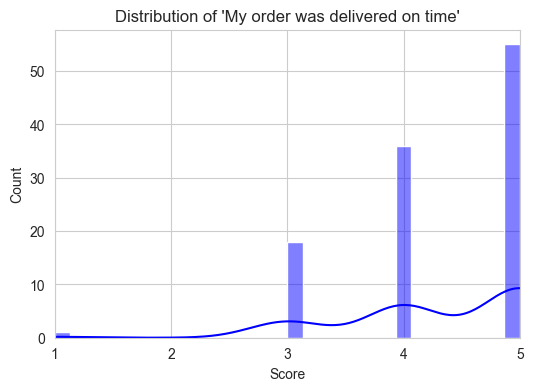

In [ ]:
# delivery_timeliness distribution - My order was delivered on time.
plt.figure(figsize=(6, 4))
sns.histplot(data["delivery_timeliness"].dropna(), kde=True, bins=30, color="blue")
plt.title("Distribution of 'My order was delivered on time'")
plt.xlabel("My order was delivered on time")
plt.xticks([1, 2, 3, 4, 5])
plt.xlim(1, 5)
plt.xlabel("Score")
plt.show()

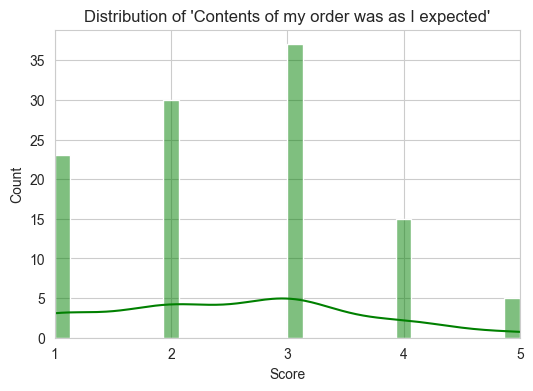

In [ ]:
# order_accuracy distribution - Contents of my order was as I expected.
plt.figure(figsize=(6, 4))
sns.histplot(data["order_accuracy"].dropna(), kde=True, bins=30, color="green")
plt.title("Distribution of 'Contents of my order was as I expected'")
plt.xlabel("Contents of my order was as I expected")
plt.xticks([1, 2, 3, 4, 5])
plt.xlim(1, 5)
plt.xlabel("Score")
plt.show()

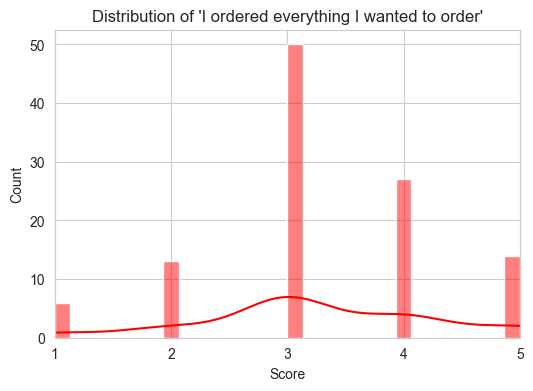

In [ ]:
# product_availability distribution - I ordered everything I wanted to order.
plt.figure(figsize=(6, 4))
sns.histplot(data["product_availability"].dropna(), kde=True, bins=30, color="red")
plt.title("Distribution of 'I ordered everything I wanted to order'")
plt.xlabel("I ordered everything I wanted to order")
plt.xticks([1, 2, 3, 4, 5])
plt.xlim(1, 5)
plt.xlabel("Score")
plt.show()

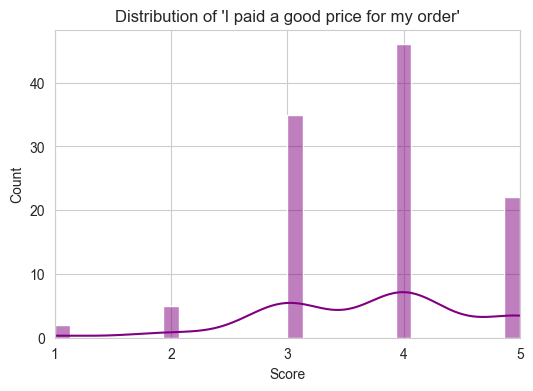

In [ ]:
# price_value_perception distribution - I paid a good price for my order.
plt.figure(figsize=(6, 4))
sns.histplot(data["price_value_perception"].dropna(), kde=True, bins=30, color="purple")
plt.title("Distribution of 'I paid a good price for my order'")
plt.xlabel("I paid a good price for my order")
plt.xticks([1, 2, 3, 4, 5])
plt.xlim(1, 5)
plt.xlabel("Score")
plt.show()

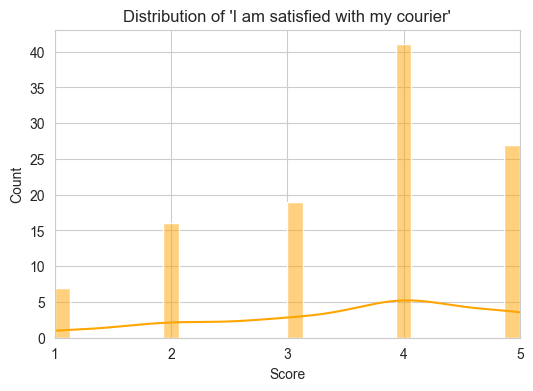

In [ ]:
# courier_service_rating distribution -I am satisfied with my courier.
plt.figure(figsize=(6, 4))
sns.histplot(data["courier_service_rating"].dropna(), kde=True, bins=30, color="orange")
plt.title("Distribution of 'I am satisfied with my courier'")
plt.xlabel("I am satisfied with my courier")
plt.xticks([1, 2, 3, 4, 5])
plt.xlim(1, 5)
plt.xlabel("Score")
plt.show()

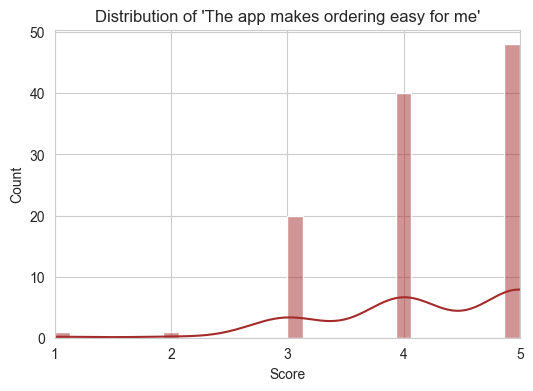

In [ ]:
# app_usability distribution - The app makes ordering easy for me.
plt.figure(figsize=(6, 4))
sns.histplot(data["app_usability"].dropna(), kde=True, bins=30, color="brown")
plt.title("Distribution of 'The app makes ordering easy for me'")
plt.xlabel("The app makes ordering easy for me")
plt.xticks([1, 2, 3, 4, 5])
plt.xlim(1, 5)
plt.xlabel("Score")
plt.show()

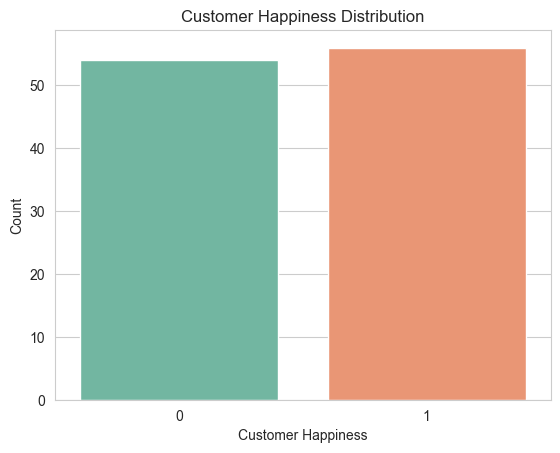

In [ ]:
# Countplot for Categorical column
sns.countplot(x="customer_happiness", data=data, palette="Set2")
plt.title("Customer Happiness Distribution")
plt.xlabel("Customer Happiness")
plt.ylabel("Count")
plt.show()

4. Bivariate analysis.

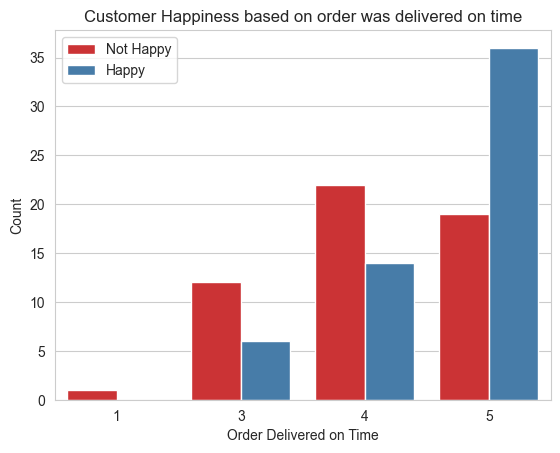

In [ ]:
# Relationship between delivery_timeliness and customer_happiness
sns.countplot(x="delivery_timeliness", hue="customer_happiness", data=data, palette="Set1")
plt.title("Customer Happiness based on order was delivered on time")
plt.xlabel("Order Delivered on Time")
plt.ylabel("Count")
plt.legend(labels=['Not Happy', 'Happy'])
plt.show()

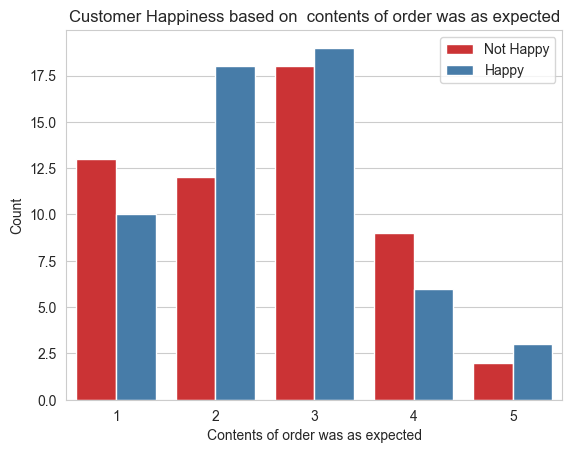

In [ ]:
# Relationship between order_accuracy and customer_happiness
sns.countplot(x="order_accuracy", hue="customer_happiness", data=data, palette="Set1")
plt.title("Customer Happiness based on  contents of order was as expected")
plt.xlabel("Contents of order was as expected")
plt.ylabel("Count")
plt.legend(labels=['Not Happy', 'Happy'])
plt.show()

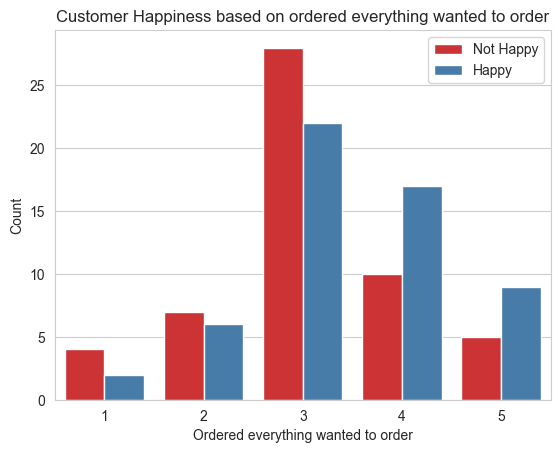

In [ ]:
# Relationship between product_availability and customer_happiness
sns.countplot(x="product_availability", hue="customer_happiness", data=data, palette="Set1")
plt.title("Customer Happiness based on ordered everything wanted to order")
plt.xlabel("Ordered everything wanted to order")
plt.ylabel("Count")
plt.legend(labels=['Not Happy', 'Happy'])
plt.show()

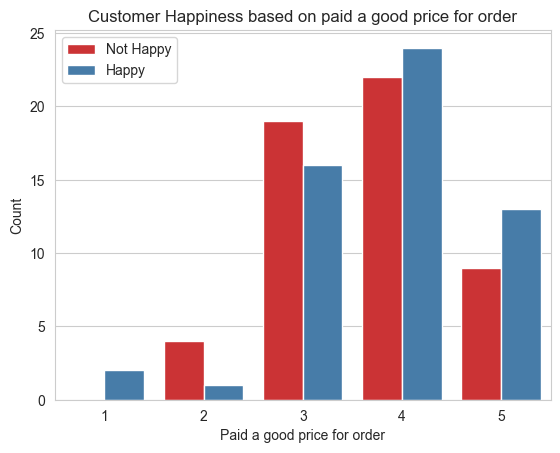

In [ ]:
# Relationship between price_value_perception and customer_happiness
sns.countplot(x="price_value_perception", hue="customer_happiness", data=data, palette="Set1")
plt.title("Customer Happiness based on paid a good price for order")
plt.xlabel("Paid a good price for order")
plt.ylabel("Count")
plt.legend(labels=['Not Happy', 'Happy'])
plt.show()

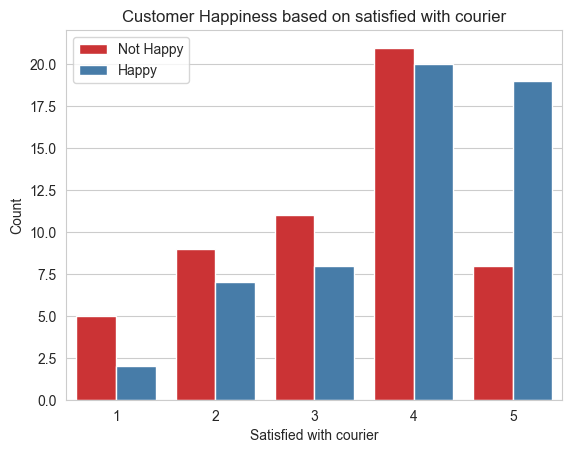

In [ ]:
# Relationship between courier_service_rating and customer_happiness
sns.countplot(x="courier_service_rating", hue="customer_happiness", data=data, palette="Set1")
plt.title("Customer Happiness based on satisfied with courier")
plt.xlabel("Satisfied with courier")
plt.ylabel("Count")
plt.legend(labels=['Not Happy', 'Happy'])
plt.show()

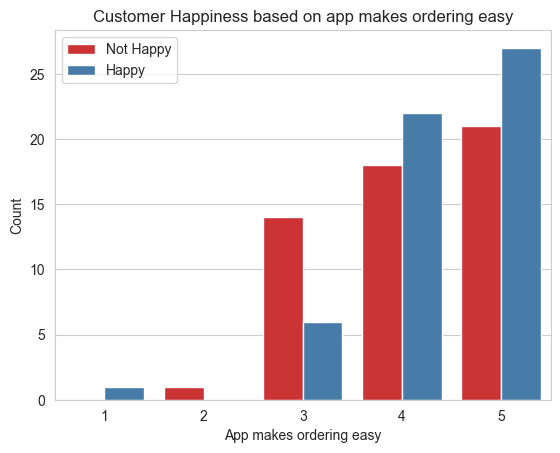

In [ ]:
# Relationship between app_usability and customer_happiness
sns.countplot(x="app_usability", hue="customer_happiness", data=data, palette="Set1")
plt.title("Customer Happiness based on app makes ordering easy")
plt.xlabel("App makes ordering easy")
plt.ylabel("Count")
plt.legend(labels=['Not Happy', 'Happy'])
plt.show()